<a href="https://colab.research.google.com/github/tamyriscabral/lia1_2026_2/blob/main/Resolu%C3%A7%C3%A3o_Desafios_Numpy_e_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐍 Fundamentos de Manipulação de Dados com NumPy e Pandas


## 🎯 Exercícios Práticos

### 💪 Desafio 1: Análise de Dados de Vendas
Usando os dados que criamos, responda às seguintes perguntas:

1. **Qual vendedor teve o maior número de vendas?**
2. **Qual região teve o maior faturamento total?**
3. **Qual é o produto mais vendido em quantidade?**
4. **Qual é a média de vendas por vendedor?**

### 🔧 Desafio 2: Limpeza de Dados
Crie um DataFrame com dados "problemáticos" e implemente:
- Remoção de duplicatas
- Tratamento de valores ausentes
- Padronização de strings
- Criação de novas colunas derivadas

### 📊 Desafio 3: Visualização
Crie gráficos que mostrem:
- Comparação entre vendedores
- Tendências por região
- Distribuição dos valores

**💡 Dica:** Use os exemplos anteriores como base e experimente modificar os parâmetros!


In [ ]:
#Cópia do código do notebook de aula

# Importando a biblioteca Pandas
import pandas as pd
print(f"Pandas versão: {pd.__version__}")

# Criando uma Series a partir de uma lista
s = pd.Series([10, 20, 30, 40], index=['a', 'b', 'c', 'd'])
print("Series:")
print(s)

# Criando um DataFrame com dados "sujos" para demonstrar limpeza
import numpy as np

dados_sujos = {
    'Nome': ['josé','João', 'Ana', 'PEDRO', 'maria', 'Carlos', ''],
    'Idade': [80, 28, 24, 35, None, 45, 30],
    'Salario': [7000, 5000, 6000, None, 4500, 7000, 5500],
    'Cidade': ['Brasília', 'São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Salvador', 'Curitiba', 'Fortaleza']
}

df_sujo = pd.DataFrame(dados_sujos)
print("DataFrame com dados 'sujos':")
df_sujo

# Verificando dados faltantes
print("Dados faltantes por coluna:")
print(df_sujo.isnull().sum())
print()

# Limpando os dados
df_limpo = df_sujo.copy()

# 1. Removendo linhas com nome vazio
df_limpo = df_limpo[df_limpo['Nome'] != '']

# 2. Padronizando nomes (primeira letra maiúscula)
df_limpo['Nome'] = df_limpo['Nome'].str.title()

# 3. Preenchendo valores faltantes
df_limpo['Idade'] = df_limpo['Idade'].fillna(df_limpo['Idade'].median())
df_limpo['Salario'] = df_limpo['Salario'].fillna(df_limpo['Salario'].mean())
print("DataFrame após limpeza:")
df_limpo

# Criando nova coluna baseada em outra
df_limpo['Faixa_Etaria'] = df_limpo['Idade'].apply(lambda x: 'Jovem' if x < 30 else 'Adulto' if x < 50 else 'Maduro')
df_limpo['Salario_Categoria'] = pd.cut(df_limpo['Salario'], bins=[0, 5000, 6000, 10000], labels=['Baixo', 'Médio', 'Alto'])

print("DataFrame com novas colunas:")
df_limpo

# Criando um DataFrame mais robusto para demonstrar groupby
np.random.seed(42)

dados_vendas = {
    'Vendedor': ['Ana', 'João', 'Pedro', 'Ana', 'João', 'Pedro', 'Ana', 'João', 'Pedro', 'Ana'] * 3,
    'Produto': ['Notebook', 'Mouse', 'Teclado', 'Monitor', 'Headset'] * 6,
    'Regiao': ['Norte', 'Sul', 'Nordeste', 'Centro-Oeste', 'Sudeste'] * 6,
    'Vendas': np.random.randint(1000, 10000, 30),
    'Quantidade': np.random.randint(1, 20, 30)
}

df_vendas_completo = pd.DataFrame(dados_vendas)
print("DataFrame de vendas:")
df_vendas_completo.head(10)

Pandas versão: 2.2.3
Series:
a    10
b    20
c    30
d    40
dtype: int64
DataFrame com dados 'sujos':
Dados faltantes por coluna:
Nome       0
Idade      1
Salario    1
Cidade     0
dtype: int64

DataFrame após limpeza:
DataFrame com novas colunas:
DataFrame de vendas:


,Vendedor,Produto,Regiao,Vendas,Quantidade
0,Ana,Notebook,Norte,8270,12
1,João,Mouse,Sul,1860,3
2,Pedro,Teclado,Nordeste,6390,5
3,Ana,Monitor,Centro-Oeste,6191,19
4,João,Headset,Sudeste,6734,7
5,Pedro,Notebook,Norte,7265,9
6,Ana,Mouse,Sul,1466,7
7,João,Teclado,Nordeste,5426,18
8,Pedro,Monitor,Centro-Oeste,6578,4
9,Ana,Headset,Sudeste,9322,14


In [ ]:
#Desafio 1
print("Qual vendedor teve o maior número de vendas?")
vendas_por_vendedor = df_vendas_completo.groupby('Vendedor')['Vendas'].sum()

print(vendas_por_vendedor.head(1))


print("\nQual região teve o maior faturamento total?")
faturamento_regiao = df_vendas_completo.groupby('Regiao')['Vendas'].sum()

print(faturamento_regiao.head(1))

print("\nQual é o produto mais vendido em quantidade?")
quantidade_por_produto = df_vendas_completo.groupby('Produto')['Quantidade'].sum()

print(quantidade_por_produto.head(1))


print("\nQual é a média de vendas por vendedor?")
media_vendas = df_vendas_completo.groupby('Vendedor')['Vendas'].mean()

print(media_vendas)

Qual vendedor teve o maior número de vendas?
Vendedor
Ana    66264
Name: Vendas, dtype: int64

Qual região teve o maior faturamento total?
Regiao
Centro-Oeste    34611
Name: Vendas, dtype: int64

Qual é o produto mais vendido em quantidade?
Produto
Headset    64
Name: Quantidade, dtype: int64

Qual é a média de vendas por vendedor?
Vendedor
Ana      5522.000000
João     4525.666667
Pedro    5677.555556
Name: Vendas, dtype: float64


In [ ]:
#Desafio 2

#DataFrame com dados problemáticos
dados_problematicos = {
    'Nome': ['ana', 'ANA', ' joão ', 'PEDRO', 'maria', 'maria', ''],
    'Idade': [25, 25, 30, None, 45, 45, 28],
    'Salario': [3000, 3000, 4500, 5000, None, None, 3500],
    'Cidade': ['São Paulo', 'São Paulo', 'Rio de Janeiro',
               'Belo Horizonte', 'Salvador', 'Salvador', 'Curitiba']
}

df_sujo = pd.DataFrame(dados_problematicos)

print("DataFrame original:")
df_sujo

DataFrame original:


,Nome,Idade,Salario,Cidade
0,ana,25.0,3000.0,São Paulo
1,ANA,25.0,3000.0,São Paulo
2,joão,30.0,4500.0,Rio de Janeiro
3,PEDRO,NaN,5000.0,Belo Horizonte
4,maria,45.0,NaN,Salvador
5,maria,45.0,NaN,Salvador
6,,28.0,3500.0,Curitiba


In [ ]:
#Tratamento de valores ausentes
df_limpo = df_limpo.copy()

print("Dados faltantes por coluna:")
print(df_limpo.isnull().sum())

Dados faltantes por coluna:
Nome                 0
Idade                1
Salario              1
Cidade               0
Faixa_Etaria         0
Salario_Categoria    1
dtype: int64


In [ ]:

df_limpo = df_limpo[df_limpo['Nome'] != ''].copy()

df_limpo['Idade'] = df_limpo['Idade'].fillna(
    df_limpo['Idade'].median()
)

df_limpo['Salario'] = df_limpo['Salario'].fillna(
    df_limpo['Salario'].mean()
)

In [ ]:
#Padronização das strings
df_limpo['Nome'] = df_limpo['Nome'].str.strip().str.title()

df_limpo['Cidade'] = df_limpo['Cidade'].str.strip().str.title()

print("DataFrame após limpeza:")
df_limpo

DataFrame após limpeza:


,Nome,Idade,Salario,Cidade,Faixa_Etaria,Salario_Categoria
0,Ana,25.0,3000.0,São Paulo,Jovem,Baixo
1,Ana,25.0,3000.0,São Paulo,Jovem,Baixo
2,João,30.0,4500.0,Rio De Janeiro,Adulto,Médio
3,Pedro,27.5,5000.0,Belo Horizonte,Maduro,Médio
4,Maria,45.0,3875.0,Salvador,Adulto,NaN


In [ ]:
#Remoção de duplicatas
df_limpo = df_limpo.drop_duplicates()

print("DataFrame após remover duplicatas:")
df_limpo

DataFrame após remover duplicatas:


,Nome,Idade,Salario,Cidade,Faixa_Etaria,Salario_Categoria
0,Ana,25.0,3000.0,São Paulo,Jovem,Baixo
2,João,30.0,4500.0,Rio De Janeiro,Adulto,Médio
3,Pedro,27.5,5000.0,Belo Horizonte,Maduro,Médio
4,Maria,45.0,3875.0,Salvador,Adulto,NaN


In [ ]:
#Criação de novas colunas derivadas
df_limpo['Faixa_Etaria'] = df_limpo['Idade'].apply(
    lambda x: 'Jovem' if x < 30 else 'Adulto' if x < 50 else 'Maduro'
)

df_limpo['Salario_Categoria'] = pd.cut(
    df_limpo['Salario'],
    bins=[0, 3000, 5000, 10000],
    labels=['Baixo', 'Médio', 'Alto']
)

In [ ]:
print("DataFrame com novas colunas:")
df_limpo

DataFrame com novas colunas:


,Nome,Idade,Salario,Cidade,Faixa_Etaria,Salario_Categoria
0,Ana,25.0,3000.0,São Paulo,Jovem,Baixo
2,João,30.0,4500.0,Rio De Janeiro,Adulto,Médio
3,Pedro,27.5,5000.0,Belo Horizonte,Jovem,Médio
4,Maria,45.0,3875.0,Salvador,Adulto,Médio


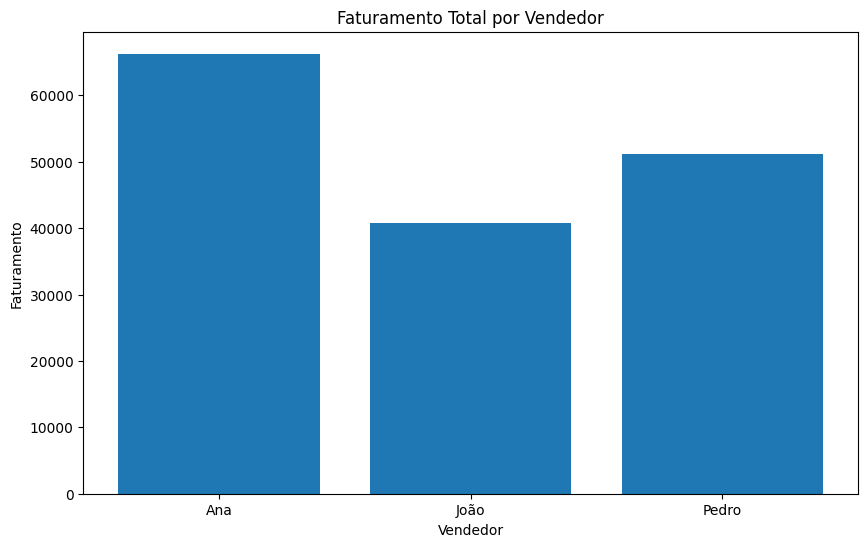

In [ ]:
#Desafio 3

import matplotlib.pyplot as plt

vendas_vendedor = df_vendas_completo.groupby('Vendedor')['Vendas'].sum()

plt.figure(figsize=(10, 6))

plt.bar(vendas_vendedor.index, vendas_vendedor.values)

plt.title('Faturamento Total por Vendedor')
plt.xlabel('Vendedor')
plt.ylabel('Faturamento')

plt.show()

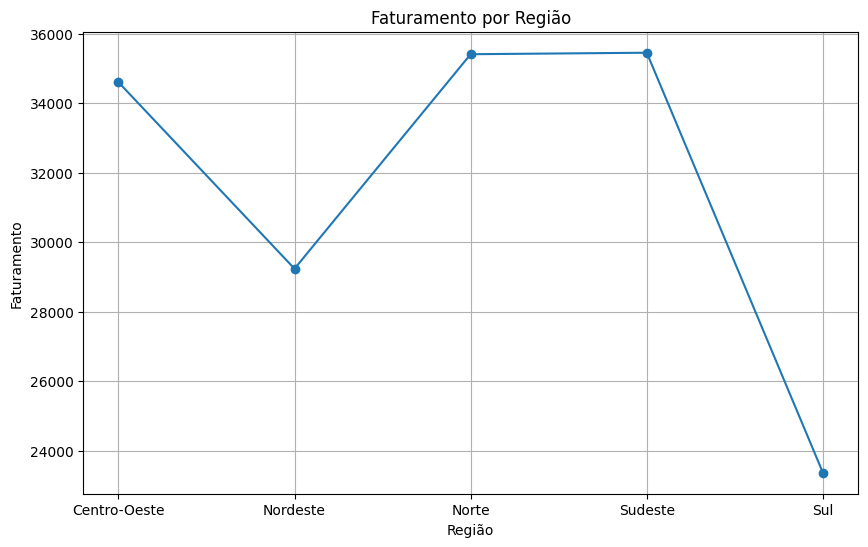

In [ ]:
vendas_regiao = df_vendas_completo.groupby('Regiao')['Vendas'].sum()

plt.figure(figsize=(10, 6))

plt.plot(vendas_regiao.index, vendas_regiao.values, marker='o')

plt.title('Faturamento por Região')
plt.xlabel('Região')
plt.ylabel('Faturamento')

plt.grid(True)

plt.show()

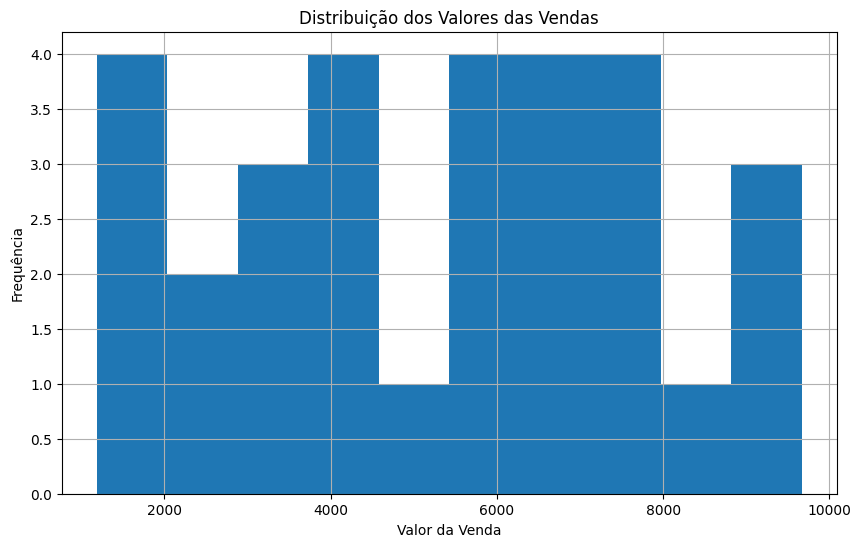

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(df_vendas_completo['Vendas'], bins=10)

plt.title('Distribuição dos Valores das Vendas')
plt.xlabel('Valor da Venda')
plt.ylabel('Frequência')

plt.grid(True)

plt.show()